# AI-Powered Intrusion Detection System Using Machine Learning

**Course:** Information Security  
**CLO:** 4  
**Task:** Classify network traffic as **Normal** or **Malicious** using CIC-IDS2017.


## 1. Dataset Setup


In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score
)

DATA_DIR = "data"
MAX_ROWS_PER_FILE = 100000

files = glob.glob(os.path.join(DATA_DIR, "*.csv"))
print("CSV files found:", len(files))
print(files)


CSV files found: 8
['data\\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv', 'data\\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv', 'data\\Friday-WorkingHours-Morning.pcap_ISCX.csv', 'data\\Monday-WorkingHours.pcap_ISCX.csv', 'data\\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv', 'data\\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv', 'data\\Tuesday-WorkingHours.pcap_ISCX.csv', 'data\\Wednesday-workingHours.pcap_ISCX.csv']


In [2]:
if not files:
    raise FileNotFoundError("Put CIC-IDS2017 CSV file(s) inside the data folder.")

frames = []
for file in files:
    temp = pd.read_csv(file, low_memory=False)
    temp.columns = temp.columns.str.strip()
    if len(temp) > MAX_ROWS_PER_FILE:
        temp = temp.sample(MAX_ROWS_PER_FILE, random_state=42)
    frames.append(temp)

df = pd.concat(frames, ignore_index=True)
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (800000, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,9392887,4,0,24,0,6,6,6.000000,0.000000,...,20,1.982000e+03,0.0000,1982,1982,9390905.0,0.0000,9390905,9390905,DDoS
1,64007,5438011,1,5,6,30,6,6,6.000000,0.000000,...,20,2.715100e+04,0.0000,27151,27151,5410860.0,0.0000,5410860,5410860,BENIGN
2,80,115615609,20,15,1728,3463,578,0,86.400000,211.017934,...,32,1.609163e+05,134508.6864,566475,120118,10100000.0,46752.4843,10100000,9988018,BENIGN
3,80,9827,3,5,26,11601,20,0,8.666667,10.263203,...,20,0.000000e+00,0.0000,0,0,0.0,0.0000,0,0,DDoS
4,53315,87583370,7,9,11607,62,4380,0,1658.142857,1762.272815,...,20,4.219842e+06,0.0000,4219842,4219842,82600000.0,0.0000,82600000,82600000,BENIGN


## 2. Dataset Inspection

In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nColumns:")
print(df.columns.tolist())
print("\nTraffic labels:")
print(df["Label"].value_counts())


Rows: 800000
Columns: 79

Columns:
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count'

In [4]:
missing_values = df.isnull().sum()

print("Total missing values:", missing_values.sum())

print("\nColumns with missing values:")
print(missing_values[missing_values > 0])

Total missing values: 230

Columns with missing values:
Flow Bytes/s    230
dtype: int64


In [5]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 55844


In [6]:
print("\nData types:")
print(df.dtypes.value_counts())


Data types:
int64      54
float64    24
object      1
Name: count, dtype: int64


## 3. Data Preprocessing

In [7]:
print("Original dataset shape:", df.shape)
df = df.dropna()
df = df.drop_duplicates()
print("Dataset shape after cleaning:", df.shape)

Original dataset shape: (800000, 79)
Dataset shape after cleaning: (744067, 79)


In [8]:
df["Attack"] = (df["Label"].str.strip().str.upper() != "BENIGN").astype(int)

print("Normal:", (df["Attack"] == 0).sum())
print("Malicious:", (df["Attack"] == 1).sum())


Normal: 611701
Malicious: 132366


In [9]:
drop_cols = [
    "Label", "Attack", "Flow ID", "Source IP",
    "Destination IP", "Timestamp"
]
drop_cols = [c for c in drop_cols if c in df.columns]

X = df.drop(columns=drop_cols)
y = df["Attack"]

X = X.apply(pd.to_numeric, errors="coerce")
X = X.replace([np.inf, -np.inf], np.nan)

valid = X.notnull().all(axis=1)
X = X.loc[valid]
y = y.loc[valid]

print("Final feature shape:", X.shape)
print("Final target shape:", y.shape)


Final feature shape: (743697, 78)
Final target shape: (743697,)


In [10]:
print("\nTarget distribution:")
print(y.value_counts())


Target distribution:
Attack
0    611377
1    132320
Name: count, dtype: int64


In [11]:
print(X.dtypes.value_counts())
print(X.isnull().sum().sum())
print(y.value_counts())

int64      54
float64    24
Name: count, dtype: int64
0
Attack
0    611377
1    132320
Name: count, dtype: int64


## 4. Exploratory Data Analysis

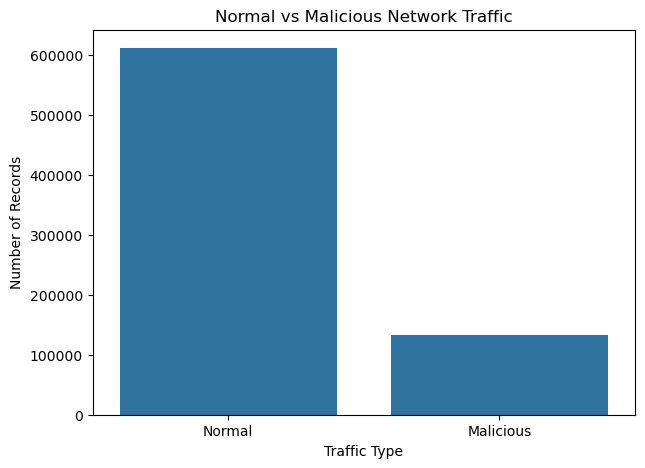

In [12]:
plt.figure(figsize=(7,5))
sns.countplot(x=df["Attack"])
plt.title("Normal vs Malicious Network Traffic")
plt.xlabel("Traffic Type")
plt.ylabel("Number of Records")
plt.xticks([0, 1], ["Normal", "Malicious"])
plt.show()


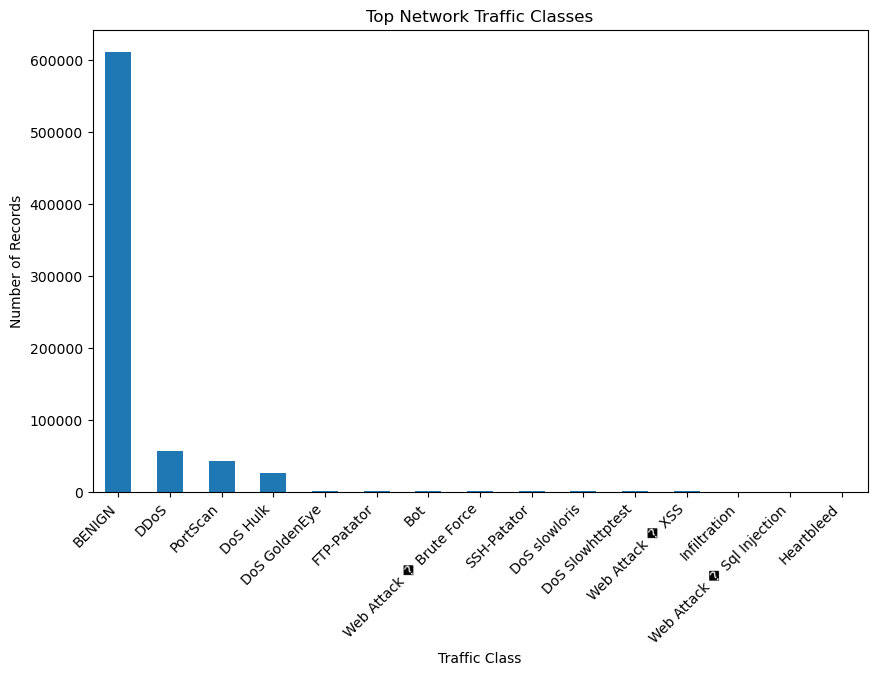

In [13]:
plt.figure(figsize=(10,6))
df["Label"].value_counts().head(15).plot(kind="bar")
plt.title("Top Network Traffic Classes")
plt.xlabel("Traffic Class")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha="right")
plt.show()


In [14]:
print(X.describe().T)

                                count          mean           std   min  \
Destination Port             743697.0  8.479908e+03  1.862510e+04   0.0   
Flow Duration                743697.0  1.395419e+07  3.268763e+07 -12.0   
Total Fwd Packets            743697.0  1.099141e+01  8.963682e+02   1.0   
Total Backward Packets       743697.0  1.267866e+01  1.196507e+03   0.0   
Total Length of Fwd Packets  743697.0  5.974112e+02  6.944192e+03   0.0   
...                               ...           ...           ...   ...   
Active Min                   743697.0  6.785737e+04  6.481200e+05   0.0   
Idle Mean                    743697.0  6.852166e+06  2.045905e+07   0.0   
Idle Std                     743697.0  6.621506e+05  5.357348e+06   0.0   
Idle Max                     743697.0  7.335714e+06  2.158713e+07   0.0   
Idle Min                     743697.0  6.342338e+06  2.002361e+07   0.0   

                               25%      50%        75%          max  
Destination Port             

In [15]:
unique_values = X.nunique().sort_values()
print(unique_values)

Fwd Avg Bulk Rate            1
Bwd Avg Bytes/Bulk           1
Fwd Avg Packets/Bulk         1
Fwd Avg Bytes/Bulk           1
Bwd Avg Packets/Bulk         1
                         ...  
Flow Duration           345517
Flow IAT Mean           370923
Fwd Packets/s           384701
Flow Packets/s          388338
Flow Bytes/s            479366
Length: 78, dtype: int64


In [16]:
constant_cols = X.columns[X.nunique() <= 1]
print("Constant columns:")
print(constant_cols)

Constant columns:
Index(['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk',
       'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk',
       'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate'],
      dtype='object')


In [17]:
correlation = X.corr()

high_corr = correlation.abs().unstack()

high_corr = high_corr[
    (high_corr > 0.90) & (high_corr < 1.00)
]

print(high_corr.sort_values(ascending=False).head(20))

Subflow Bwd Bytes            Total Length of Bwd Packets    1.000000
Total Length of Bwd Packets  Subflow Bwd Bytes              1.000000
Bwd Header Length            Fwd Header Length.1            0.999991
Fwd Header Length.1          Bwd Header Length              0.999991
Fwd Header Length            Bwd Header Length              0.999991
Bwd Header Length            Fwd Header Length              0.999991
Total Fwd Packets            Subflow Bwd Packets            0.999290
Total Backward Packets       Total Fwd Packets              0.999290
                             Subflow Fwd Packets            0.999290
Total Fwd Packets            Total Backward Packets         0.999290
Subflow Fwd Packets          Total Backward Packets         0.999290
                             Subflow Bwd Packets            0.999290
Subflow Bwd Packets          Total Fwd Packets              0.999290
                             Subflow Fwd Packets            0.999290
Fwd IAT Total                Flow 

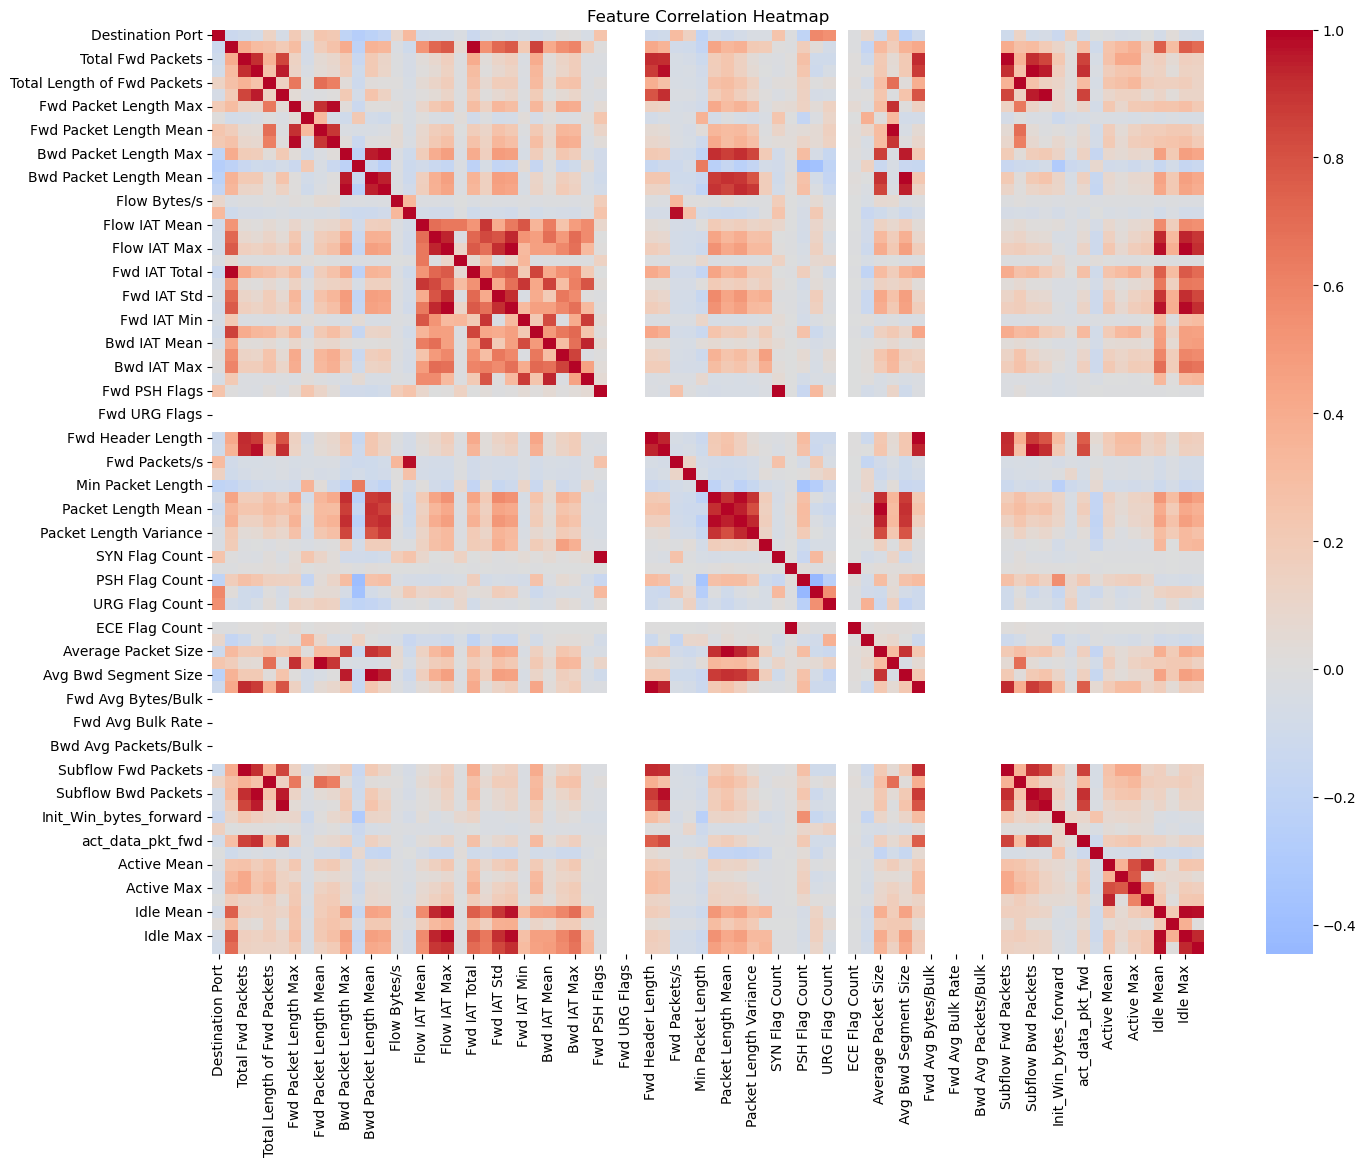

In [21]:
sample_X = X.sample(5000, random_state=42)

plt.figure(figsize=(16, 12))

sns.heatmap(
    sample_X.corr(),
    cmap="coolwarm",
    center=0,
    
)

plt.title("Feature Correlation Heatmap")
plt.show()

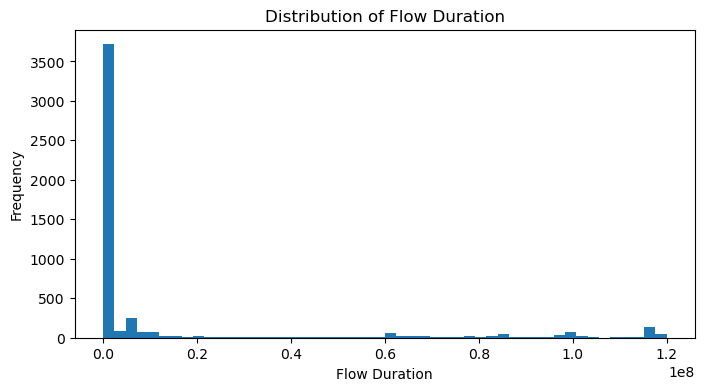

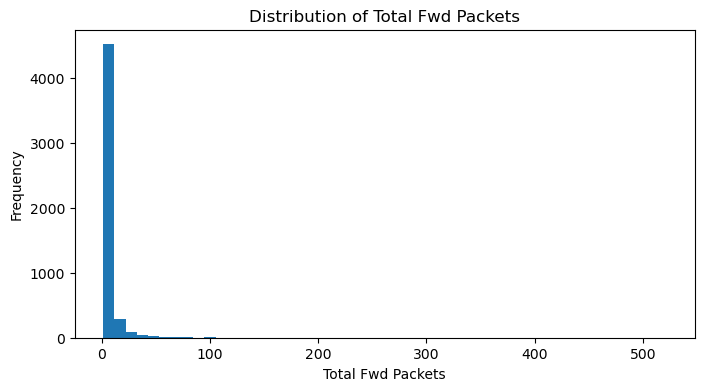

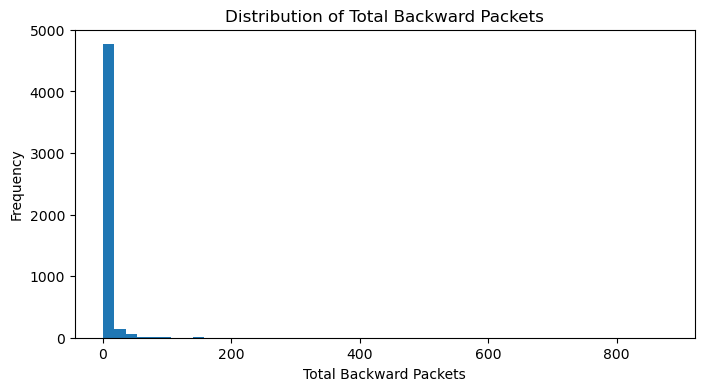

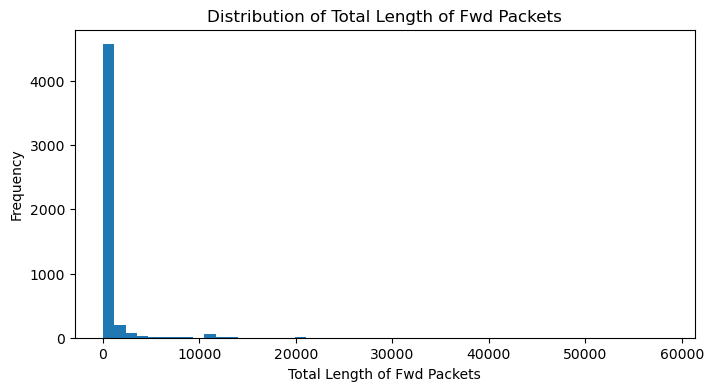

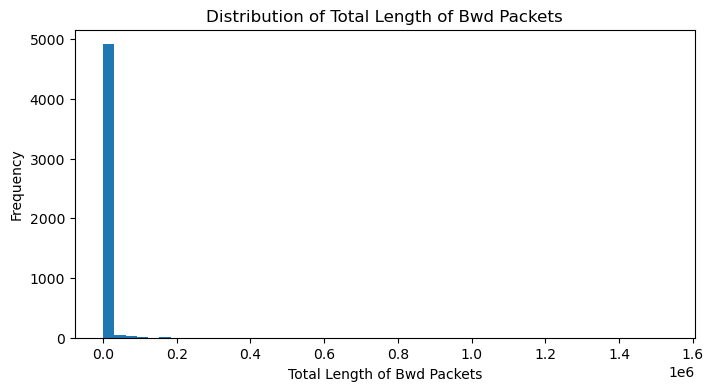

In [22]:
features = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Total Length of Fwd Packets",
    "Total Length of Bwd Packets"
]

for feature in features:
    if feature in X.columns:
        plt.figure(figsize=(8, 4))
        plt.hist(X[feature].sample(5000, random_state=42), bins=50)
        plt.title(f"Distribution of {feature}")
        plt.xlabel(feature)
        plt.ylabel("Frequency")
        plt.show()

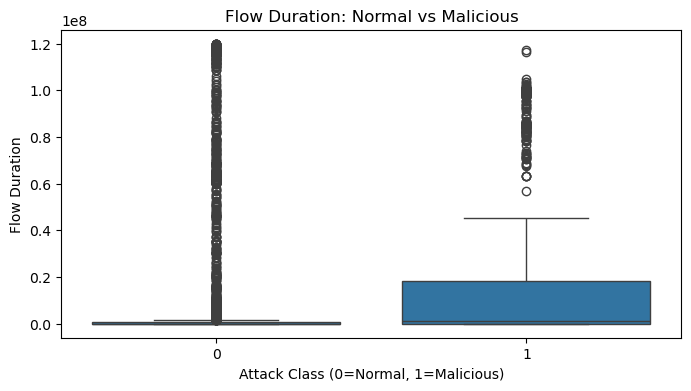

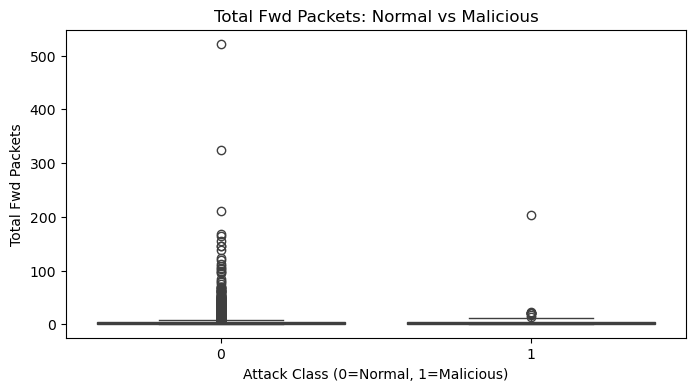

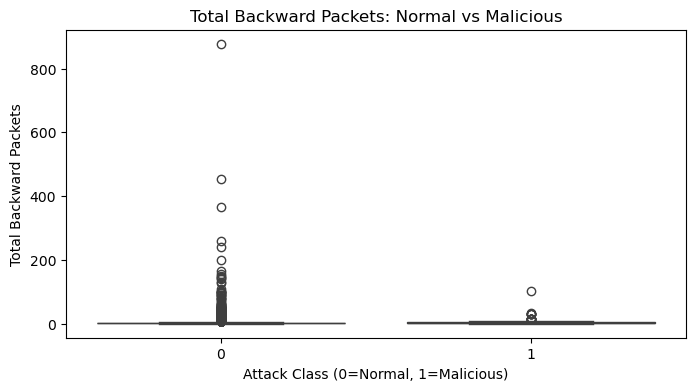

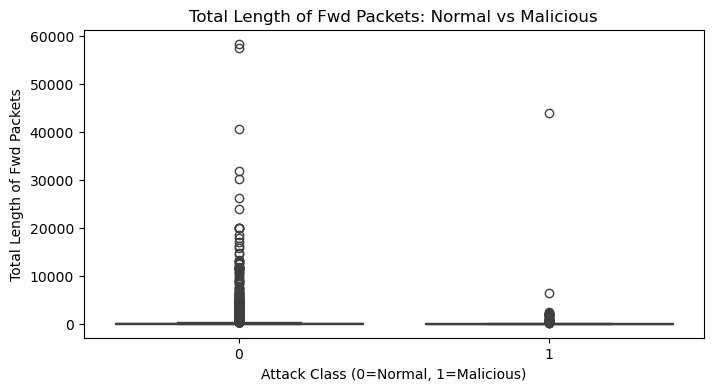

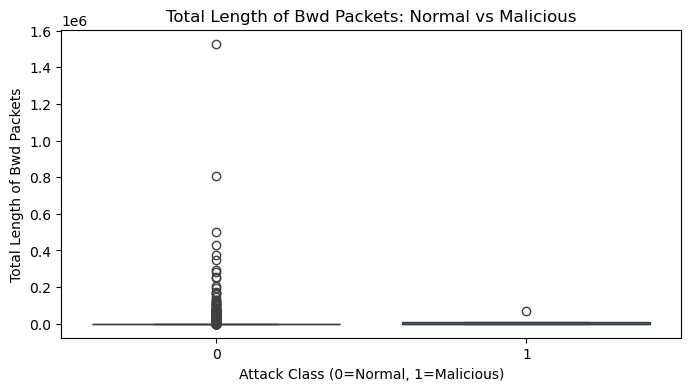

In [23]:
eda_df = X.copy()
eda_df["Attack"] = y

features = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Total Length of Fwd Packets",
    "Total Length of Bwd Packets"
]

for feature in features:
    if feature in eda_df.columns:
        plt.figure(figsize=(8, 4))

        sns.boxplot(
            data=eda_df.sample(5000, random_state=42),
            x="Attack",
            y=feature
        )

        plt.title(f"{feature}: Normal vs Malicious")
        plt.xlabel("Attack Class (0=Normal, 1=Malicious)")
        plt.ylabel(feature)
        plt.show()

## 5. Train/Test Split and Scaling

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (594957, 78)
X_test: (148740, 78)
y_train: (594957,)
y_test: (148740,)


In [25]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 594957
Testing rows: 148740


## 6. Machine Learning Models

In [27]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

lr_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [28]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [29]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 7. Predictions and Evaluation

In [30]:
y_pred_lr = lr_model.predict(X_test_scaled)

In [31]:
y_pred_dt = dt_model.predict(X_test)

In [32]:
y_pred_rf = rf_model.predict(X_test)

In [34]:
from sklearn.metrics import f1_score

models = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf
}

results = []

for name, predictions in models.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions)
    })

results_df = pd.DataFrame(results)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.930180   0.727265  0.972151  0.832064
1        Decision Tree  0.998064   0.994783  0.994332  0.994557
2        Random Forest  0.998023   0.995606  0.993274  0.994439


In [35]:
print("=== Logistic Regression ===")
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["Normal", "Malicious"]
))

print("=== Decision Tree ===")
print(classification_report(
    y_test,
    y_pred_dt,
    target_names=["Normal", "Malicious"]
))

print("=== Random Forest ===")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["Normal", "Malicious"]
))

=== Logistic Regression ===
              precision    recall  f1-score   support

      Normal       0.99      0.92      0.96    122276
   Malicious       0.73      0.97      0.83     26464

    accuracy                           0.93    148740
   macro avg       0.86      0.95      0.89    148740
weighted avg       0.95      0.93      0.93    148740

=== Decision Tree ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    122276
   Malicious       0.99      0.99      0.99     26464

    accuracy                           1.00    148740
   macro avg       1.00      1.00      1.00    148740
weighted avg       1.00      1.00      1.00    148740

=== Random Forest ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    122276
   Malicious       1.00      0.99      0.99     26464

    accuracy                           1.00    148740
   macro avg       1.00      1.00      1.00    148740
we

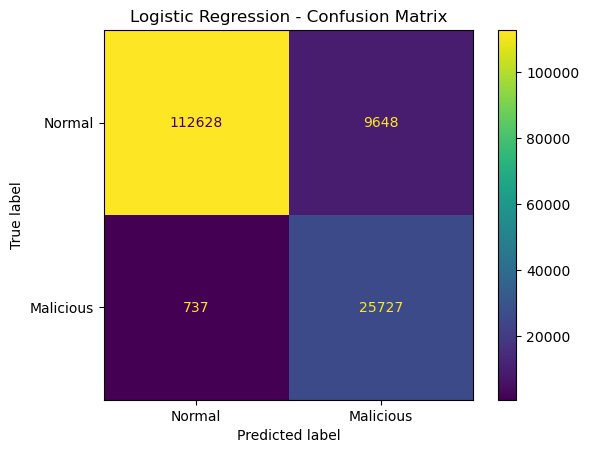

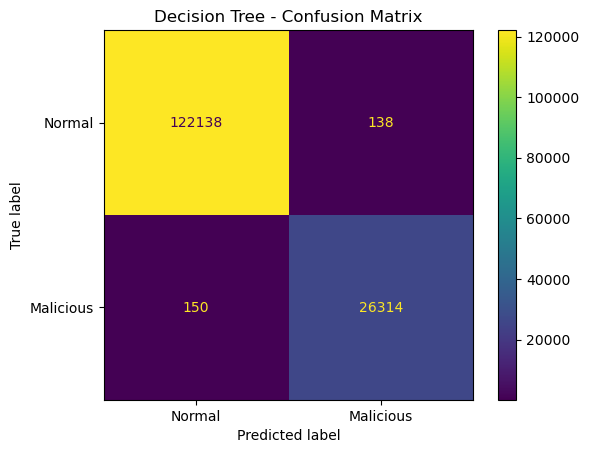

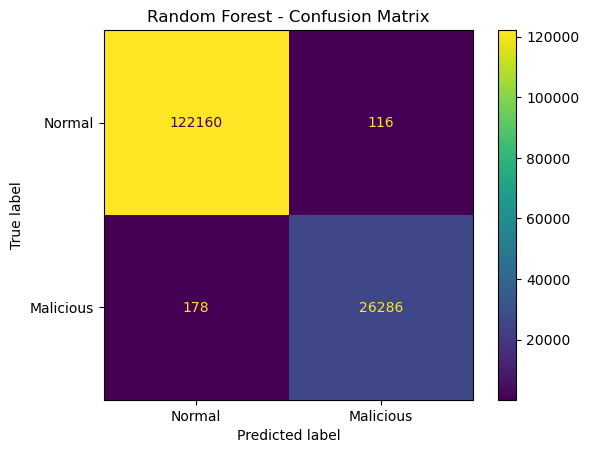

In [37]:
from sklearn.metrics import ConfusionMatrixDisplay

predictions = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf
}

for name, predictions_model in predictions.items():
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions_model,
        display_labels=["Normal", "Malicious"]
    )
    
    plt.title(f"{name} - Confusion Matrix")
    plt.show()

In [40]:
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]
auc_lr = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression ROC-AUC:", auc_lr)

Logistic Regression ROC-AUC: 0.9838601621530344


In [41]:
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]
auc_dt = roc_auc_score(y_test, y_prob_dt)

print("Decision Tree ROC-AUC:", auc_dt)

Decision Tree ROC-AUC: 0.9966094974823149


In [42]:
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest ROC-AUC:", auc_rf)

Random Forest ROC-AUC: 0.9996927907865422


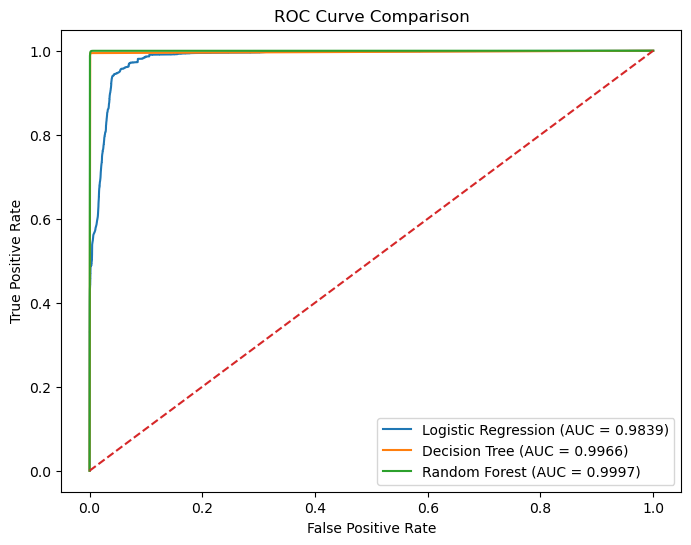

In [62]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.4f})")
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.4f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

##  8. Checking for data leakage

In [44]:
print("Attack in X:", "Attack" in X.columns)
print("Label in X:", "Label" in X.columns)

Attack in X: False
Label in X: False


In [45]:
print(X.columns.tolist())

['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count

In [46]:
train_features = X_train.copy()
test_features = X_test.copy()

train_hash = pd.util.hash_pandas_object(
    train_features,
    index=False
)

test_hash = pd.util.hash_pandas_object(
    test_features,
    index=False
)

overlap = len(set(train_hash) & set(test_hash))

print("Duplicate feature rows shared between train and test:", overlap)

Duplicate feature rows shared between train and test: 43


In [47]:
print("Training:")
print(y_train.value_counts())

print("\nTesting:")
print(y_test.value_counts())

Training:
Attack
0    489101
1    105856
Name: count, dtype: int64

Testing:
Attack
0    122276
1     26464
Name: count, dtype: int64


In [48]:
feature_target_corr = X.copy()

feature_target_corr["Attack"] = y

correlations = (
    feature_target_corr.corr()["Attack"]
    .drop("Attack")
    .abs()
    .sort_values(ascending=False)
)

print(correlations.head(15))

Bwd Packet Length Std     0.525436
Bwd Packet Length Max     0.504687
Bwd Packet Length Mean    0.499858
Avg Bwd Segment Size      0.499858
Packet Length Std         0.477265
Packet Length Variance    0.464584
Max Packet Length         0.455427
Average Packet Size       0.428022
Packet Length Mean        0.426768
Fwd IAT Std               0.343616
Idle Max                  0.305939
Flow IAT Max              0.302118
Fwd IAT Max               0.301162
Idle Mean                 0.297110
Min Packet Length         0.291307
Name: Attack, dtype: float64


## 9. Feature Importance

In [51]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(15))

                    Feature  Importance
8    Fwd Packet Length Mean    0.057894
39        Max Packet Length    0.057042
42   Packet Length Variance    0.051378
11    Bwd Packet Length Min    0.041719
38        Min Packet Length    0.041081
67  Init_Win_bytes_backward    0.038230
53     Avg Fwd Segment Size    0.036598
63        Subflow Fwd Bytes    0.035613
13    Bwd Packet Length Std    0.034156
66   Init_Win_bytes_forward    0.031830
6     Fwd Packet Length Max    0.031499
10    Bwd Packet Length Max    0.031169
0          Destination Port    0.030935
41        Packet Length Std    0.029841
52      Average Packet Size    0.029482


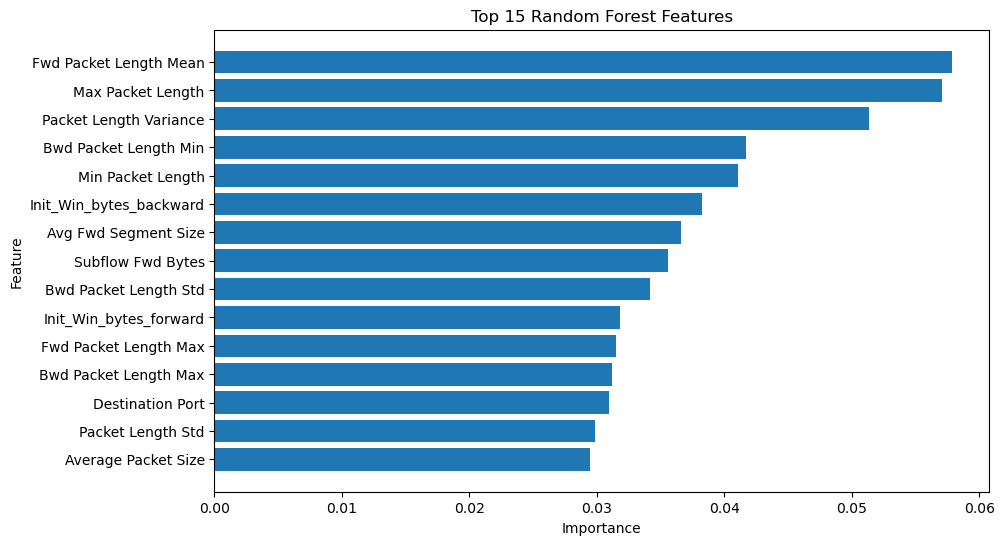

In [52]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))
plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Features")
plt.show()

## 10. Results Table

In [55]:
auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_dt = roc_auc_score(y_test, y_prob_dt)
auc_rf = roc_auc_score(y_test, y_prob_rf)

results_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        auc_lr,
        auc_dt,
        auc_rf
    ]
})

results_display = results_df.copy()

for column in results_display.columns[1:]:
    results_display[column] = results_display[column] * 100

results_display.round(2)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,93.02,72.73,97.22,83.21,98.39
1,Decision Tree,99.81,99.48,99.43,99.46,99.66
2,Random Forest,99.80,99.56,99.33,99.44,99.97


In [56]:
import joblib

joblib.dump(rf_model, "random_forest_model.pkl")

joblib.dump(scaler, "scaler.pkl")

print("Models saved successfully.")

Models saved successfully.


In [57]:
joblib.dump(X_train.columns.tolist(), "feature_names.pkl")

print("Feature names saved successfully.")

Feature names saved successfully.


In [58]:
joblib.dump(
    {
        "fpr_lr": fpr_lr,
        "tpr_lr": tpr_lr,
        "fpr_dt": fpr_dt,
        "tpr_dt": tpr_dt,
        "fpr_rf": fpr_rf,
        "tpr_rf": tpr_rf
    },
    "roc_data.pkl"
)

print("ROC data saved.")

ROC data saved.


In [59]:
normal_sample = X[y == 0].iloc[[0]]

malicious_sample = X[y == 1].iloc[[0]]

normal_sample.to_csv("normal_test.csv", index=False)
malicious_sample.to_csv("malicious_test.csv", index=False)

print("Both test files saved successfully.")

Both test files saved successfully.


In [60]:
normal_sample = X[y == 0].iloc[[0]]
malicious_sample = X[y == 1].iloc[[0]]

normal_sample.to_csv(
    r"C:\Users\hafsa\Desktop\IDS_Dashboard\normal_test.csv",
    index=False
)

malicious_sample.to_csv(
    r"C:\Users\hafsa\Desktop\IDS_Dashboard\malicious_test.csv",
    index=False
)

print("Normal sample shape:", normal_sample.shape)
print("Malicious sample shape:", malicious_sample.shape)
print("Normal sample saved.")
print("Malicious sample saved.")

Normal sample shape: (1, 78)
Malicious sample shape: (1, 78)
Normal sample saved.
Malicious sample saved.


In [61]:
test = pd.read_csv(
    r"C:\Users\hafsa\Desktop\IDS_Dashboard\normal_test.csv"
)

print(test.shape)
print(test.columns.tolist())

(1, 78)
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Fl